## 1: Business Scenario Review

HealthConnect Clinic is seeking to reduce missed appointments, improve appointment attendance, and provide more effective administrative support to patients, using data and AI. Week 6 moves the project from initial implementation into Integration → Advanced Development → Validation. The focus is no longer on producing an individual component, but on demonstrating how this work connects to the broader HealthConnect solution, improving output quality, and validating readiness for the next stage.

## 2: Week 5 → Week 6 Transition

**1. Main Week 5 output:** A baseline Logistic Regression model predicting appointment no-shows, built on 9 finalized features (8 statistically-tested original candidates + prior_no_show_rate), using a patient-level 80/20 train/test split.

**2. Most important result/component:** The trained baseline itself showed Accuracy 0.63, Recall 0.62, ROC-AUC 0.68 and the evidence-based feature list that survived t-test/chi-square screening.

**3. Main issue/limitation discovered:** Recall of 0.62 means the model misses 38% of actual no-shows (183 out of 483 in the test set) and for HealthConnect's use case, missed no-shows are the costlier error, so this is the priority to fix. Another likely limitation was Logistic Regression's assumption of linearity, which may have capped its performance

**4. Track(s) relevant to Week 6 activities:** Machine Learning Engineering (they need the improved model/feature spec for their pipeline integration).

**5. What I intend to improve/integrate/validate:** Improve on the baseline by testing a Random Forest (non-linear, per Week 5's own recommendation), conduct error analysis on the false negatives, and validate whether the improved model is a better fit before handing it off to ML Engineering.

##  3: Baseline Performance Summary

This is for continuity, see Week 5 notebook for full analysis/justification)

In [1]:
import joblib
import pandas as pd
import numpy as np

log_model = joblib.load("week5_baseline_model.pkl")
X_train = pd.read_csv("week5_X_train.csv")
X_test = pd.read_csv("week5_X_test.csv")
y_train = pd.read_csv("week5_y_train.csv").squeeze()
y_test = pd.read_csv("week5_y_test.csv").squeeze()

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

# Also reload the pre-split, pre-encoded dataset — needed for testing new 
# interaction features on raw (unencoded) columns like reminder_channel
df = pd.read_csv("HealthConnect_ML_Processed.csv")
df = df.drop(columns=['appointment_id', 'waiting_time_minutes', 'gender', 'age_group',
                       'appointment_day', 'appointment_time'])
df['is_first_time_patient'] = (df['previous_appointments'] == 0).astype(int)
df['prior_no_show_rate'] = np.where(
    df['is_first_time_patient'] == 1,
    0,
    df['previous_no_shows'] / df['previous_appointments']
)

# Reapply Week 5's median imputation (the saved CSV predates this step)
median_distance = df['distance_to_clinic_km'].median()
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(median_distance)

In [2]:
week5_fingerprint = set(
    X_test[['age', 'booking_lead_days', 'previous_appointments',
            'previous_no_shows', 'distance_to_clinic_km']]
    .round(6)
    .apply(tuple, axis=1)
)
print("Week 5 test set size:", len(week5_fingerprint))

Week 5 test set size: 966


## Week 6 Integration Readiness

#### A. Integration Point
- **Track working with:** Data Analytics
  
- **Output needed from that track:** A validated finding or pattern from their analysis of no-show behaviour (e.g. a patient segment, time-based trend, or KPI) that isn't  currently captured in my model's feature set.

- **Output provided to that track:** My finalized feature list and baseline model results (62% recall, 0.68 ROC-AUC), including which features tested weak or borderline, so they can see what's already been tried and where a gap might exist.
  
- **Why this connection is relevant:** Data Analytics' Week 6 tasks include validating KPIs and identifying findings with the greatest business impact. some of those findings may point to patterns my baseline model hasn't tested. Bringing a validated finding into the model (rather than just noting it) is a direct way to improve the model using work already done elsewhere in the project.

#### B. Integration Objective
After this integration activity, my model should be tested against at least one new pattern or feature suggested by Data Analytics' findings, and I should know whether it meaningfully changes the model's performance or feature decisions turning their finding into an actual, tested part of my model rather than just information exchanged.

##  Error Analysis

#### Step 1: Isolate misclassified patients

In [3]:
# Attach predictions back to the test set for inspection
X_test_analysis = X_test.copy()
X_test_analysis['actual'] = y_test.values
X_test_analysis['predicted'] = y_pred
X_test_analysis['predicted_proba'] = y_proba

# False negatives: model said Attended, but they actually No-Showed
false_negatives = X_test_analysis[(X_test_analysis['actual'] == 1) & (X_test_analysis['predicted'] == 0)]

# False positives: model said No-Show, but they actually Attended
false_positives = X_test_analysis[(X_test_analysis['actual'] == 0) & (X_test_analysis['predicted'] == 1)]

# Correctly predicted no-shows, for comparison
true_positives = X_test_analysis[(X_test_analysis['actual'] == 1) & (X_test_analysis['predicted'] == 1)]

print("False negatives:", false_negatives.shape[0])
print("False positives:", false_positives.shape[0])
print("True positives:", true_positives.shape[0])

False negatives: 183
False positives: 178
True positives: 300


#### Step 1 Result: Confirming Misclassified Groups

Isolating the test set predictions confirms 183 false negatives (missed no-shows), 178 false positives (patients wrongly flagged as no-show), and 300 true positives (correctly caught no-shows) and this matches the Week 5 confusion matrix exactly. This confirms the reloaded baseline model and test set are reproducing Week 5's results correctly, so any error analysis from here reflects the same model Week 5 evaluated.

#### Step 2: Compare feature values: false negatives vs. correctly caught no-shows

In [4]:
compare_cols = ['booking_lead_days', 'previous_no_shows', 'previous_appointments',
                'distance_to_clinic_km', 'age', 'prior_no_show_rate']

comparison = pd.DataFrame({
    'False Negatives (missed)': false_negatives[compare_cols].mean(),
    'True Positives (caught)': true_positives[compare_cols].mean()
})

comparison['Difference'] = comparison['False Negatives (missed)'] - comparison['True Positives (caught)']
print(comparison)

                       False Negatives (missed)  True Positives (caught)  \
booking_lead_days                     -0.339503                 0.481505   
previous_no_shows                      0.404372                 0.706667   
previous_appointments                 -0.043716                 0.133333   
distance_to_clinic_km                  0.118074                 0.311350   
age                                   -0.007403                -0.061183   
prior_no_show_rate                     0.397035                 0.616480   

                       Difference  
booking_lead_days       -0.821008  
previous_no_shows       -0.302295  
previous_appointments   -0.177049  
distance_to_clinic_km   -0.193276  
age                      0.053779  
prior_no_show_rate      -0.219445  


#### Step 2 Result: Numeric Feature Comparison — Missed vs. Caught No-Shows

Across every numeric feature, the false negatives (missed no-shows) score lower than the true positives (correctly caught no-shows) except age, where the two groups are nearly identical.

- **booking_lead_days** shows the largest gap (-0.82), missed no-shows booked with a much shorter lead time than the no-shows the model caught. Since long lead time was the model's strongest signal (from Week 5), patients who had no-show but book close to their appointment date don't trigger this signal at all.
  
- **previous_no_shows** and **prior_no_show_rate** also show large gaps (-0.30 and -0.22), missed no-shows have a noticeably cleaner attendance history than the no-shows the model catches. In other words, the model is good at catching "repeat offenders" but blind to patients with no prior red flags with no-show anyway.
 
- **distance_to_clinic_km** (-0.19) follows the same pattern: missed no-shows tend to live closer to the clinic, the opposite of what the model expects a no-show to look like.
  
- **age** shows almost no difference (+0.05), consistent with Week 5's finding that age was  only a borderline predictor.  

**Interpretation:** The model has essentially learned one profile of a no-show which is someone who books far ahead and has a history of missing appointments. It reliably catches that profile, but it has no signal at all for a no-show who looks "safe" on paper which are recent 
booking, clean history, lives close by. These are exactly the patients Week 5's recommendations pointed toward addressing (via a non-linear model or additional features), since Logistic Regression can only weigh these features in one linear direction, whereas a model like Random Forest could pick up more complex, patient-specific combinations.

#### Step 2b: Compare categorical (one-hot encoded) features — false negatives vs. correctly caught no-shows

In [5]:
dummy_cols = ['appointment_type_Follow-up', 'appointment_type_General Consultation',
              'appointment_type_Specialist Consultation', 'reminder_sent_Yes',
              'reminder_channel_No Reminder', 'reminder_channel_SMS', 'reminder_channel_WhatsApp']

comparison_cat = pd.DataFrame({
    'False Negatives (missed)': false_negatives[dummy_cols].mean(),
    'True Positives (caught)': true_positives[dummy_cols].mean()
})

comparison_cat['Difference'] = comparison_cat['False Negatives (missed)'] - comparison_cat['True Positives (caught)']
print(comparison_cat)

                                          False Negatives (missed)  \
appointment_type_Follow-up                                0.234973   
appointment_type_General Consultation                     0.464481   
appointment_type_Specialist Consultation                  0.234973   
reminder_sent_Yes                                         0.797814   
reminder_channel_No Reminder                              0.202186   
reminder_channel_SMS                                      0.502732   
reminder_channel_WhatsApp                                 0.202186   

                                          True Positives (caught)  Difference  
appointment_type_Follow-up                               0.310000   -0.075027  
appointment_type_General Consultation                    0.393333    0.071148  
appointment_type_Specialist Consultation                 0.170000    0.064973  
reminder_sent_Yes                                        0.670000    0.127814  
reminder_channel_No Reminder           

#### Step 2b Result: Categorical Feature Comparison — Missed vs. Caught No-Shows

- **appointment_type_Follow-up:** missed no-shows are less likely to be Follow-up appointments than caught no-shows (23% vs 31%). Since Week 5 found Follow-up appointments carry a higher no-show rate overall, this makes sense and the model has partly learned to flag Follow-up appointments as risky, so a no-show in a *different* appointment type is  more likely to slip past it.

- **reminder_sent_Yes:** the biggest gap here (0.80 vs 0.67), missed no-shows are more likely to have received a reminder than the no-shows the model catches. This is counter-intuitive at first, but combined with the reminder_channel numbers below, it points to *which* reminder channel actually matters, not just whether a reminder was sent.

- **reminder_channel_SMS:** missed no-shows are more likely to have received an SMS reminder (50% vs 32%) and the channel Week 5 found was associated with *better* attendance. This means a meaningful share of the model's missed no-shows are patients who "did everything right" on paper (got a reminder, via the most effective channel) but still didn't show up.

- **reminder_channel_No Reminder** is markedly lower among missed no-shows (20% vs 33%), reinforcing the same point: the model expects "no reminder" to signal risk, so a no-show  who did get reminded isn't flagged.

**Interpretation:** Combined with the numeric findings, this confirms the model has learned a fairly narrow "high-risk" profile and the features are  long lead time, prior no-show history, no reminder, Follow-up type. The model reliably catches patients who match these features. But a real, distinct group of no-shows looks the *opposite* on paper (recent booking, clean history, got an SMS reminder, non-Follow-up appointment) and the model has no way to catch them at all. This isn't a matter of tuning the same features harder but it suggests either an interaction the current 
features don't capture (e.g. reminder effectiveness may depend on appointment type ), or a non-linear model that can pick up on more complex combinations Logistic Regression's linear structure misses.

### Validating Data Analytics' Finding(Claudia)

Data Analytics (Claudia) shared that patients with no reminder_channel recorded appear to have a very high no-show rate. This is checked directly against the dataset below before being incorporated into any modelling decisions.

In [6]:
# Check: does missing reminder_channel perfectly predict no-show?
crosstab = pd.crosstab(df['reminder_channel'].isna(), df['appointment_outcome'], normalize='index')
crosstab.index = ['Has reminder channel', 'No reminder channel (missing)']
crosstab.columns = ['Attended', 'No-Show']
print(crosstab)

                               Attended   No-Show
Has reminder channel           0.501448  0.498552
No reminder channel (missing)  0.453696  0.546304


### Validation Result

Following up with Claudia confirmed both tracks handled reminder_channel's missing values the same way (matching reminder_sent = No), and that the 348-record gap in missing-value counts (1,633 vs. 1,285) is most likely explained by Cancelled appointments because these were excluded from this analysis but retained (and handled separately) in hers.

Even accounting for that, the claim that "not setting a reminder is almost equivalent to a no-show" does not hold up against this dataset: the actual no-show rate for patients without a reminder is 54.6%, compared to 49.9% for those with one which is a real but modest 5 point difference, not a near-equivalence. This is consistent with Week 5's own chi-square test for reminder_sent (statistically significant, p = 0.0038, but a modest real-world effect size), so this validation reinforces Week 5's existing conclusion rather than revealing a stronger signal than previously found.

A second, unresolved disagreement also emerged from this exchange: Claudia reported no correlation between distance_to_clinic_km and no-shows, whereas this analysis found it to be the single most important feature in the Random Forest model. This discrepancy has been flagged back to her and is not yet resolved and it is noted as an open item for further discussion rather than a settled conclusion.

**Decision:** No new feature is added based on this specific finding, since reminder_sent/reminder_channel are already captured in the current feature set and this check confirms their existing effect size. The distance_to_clinic_km disagreement is carried forward as an open cross-track question.

### Validating Data Analytics' Finding (Angela)

Data Analytics (Angela) shared that booking lead time and prior no-show history compound rather than act independently, reporting a no-show rate of 21.8% for patients with neither risk factor, rising to 67.9% for patients with both a long lead time and a prior no-show. 
This is checked directly against the dataset below before deciding whether to build a new feature from it.

In [7]:
# Replicate Angela's check: no-show rate by lead-time band and prior no-show history
df['had_prior_noshow'] = (df['previous_no_shows'] > 0).astype(int)
df['lead_time_band'] = pd.cut(df['booking_lead_days'], bins=[-1, 7, 30, 60],
                               labels=['0-7 days', '8-30 days', '31-60 days'])

check_angela = df.groupby(['lead_time_band', 'had_prior_noshow'], observed=True)['appointment_outcome'].mean() * 100
print(check_angela.round(1))

lead_time_band  had_prior_noshow
0-7 days        0                   22.8
                1                   39.0
8-30 days       0                   38.4
                1                   47.8
31-60 days      0                   59.1
                1                   70.5
Name: appointment_outcome, dtype: float64


### Validation Result

This confirms Angela's core finding: no-show rate rises with both booking lead time and prior no-show history, and the two factors compound rather than act independently. The 0-7 day, no-prior-no-show group sits lowest (22.8%), while the 31-60 day, prior-no-show group sits highest (70.5%).

The exact figures differ slightly from Angela's reported 21.8% and 67.9% maybe likely due to this analysis excluding Cancelled appointments (263 records), the same data-scope difference already identified in the Claudia exchange. The direction and overall pattern are fully consistent regardless.

**Decision:** Since this compounding pattern is confirmed and directly relevant to the gap identified in this notebook's error analysis (the model missing "safe-looking" no-shows), an interaction feature (`lead_and_prior_noshow`) is built and statistically tested in the Feature Refinement section below.

## Feature Refinement

Two candidate interaction features are tested in this section:

1. **recent_and_sms** — built from this notebook's own error analysis, which showed missed no-shows often combine a recent booking with an SMS reminder.
   
2. **lead_and_prior_noshow** — built from a finding shared by the Data Analytics track (Angela): long lead time and prior no-show history compound rather than act independently, directly targeting the same gap identified in this notebook's error analysis.

In [8]:
# Build and statistically test the interaction feature on the full dataset first, before deciding whether it's worth adding to the model
median_lead = df['booking_lead_days'].median()
df['recent_booking_flag'] = (df['booking_lead_days'] < median_lead).astype(int)
df['recent_and_sms'] = df['recent_booking_flag'] * (df['reminder_channel'] == 'SMS').astype(int)

from scipy import stats
attended = df[df['appointment_outcome'] == 0]['recent_and_sms']
no_show = df[df['appointment_outcome'] == 1]['recent_and_sms']
t_stat, p_val = stats.ttest_ind(attended, no_show)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")

T-statistic: 10.500, P-value: 0.0000


### Feature Refinement Result - recent_and_sms

The interaction feature (recent booking + SMS reminder) is highly statistically significant (T-statistic = 10.500, p < 0.0001) and far stronger than most of the individual features tested in Week 5. This confirms the pattern the error analysis pointed to, a patient who books close 
to their appointment date *and* receives an SMS reminder behaves differently from what either signal predicts on its own, and this combination is not currently captured anywhere in the existing feature set.

**Decision:**  recent_and_sms is added to the feature set going into the improved model.

In [9]:
df['had_prior_noshow'] = (df['previous_no_shows'] > 0).astype(int)
df['lead_and_prior_noshow'] = df['booking_lead_days'] * df['had_prior_noshow']

t_stat2, p_val2 = stats.ttest_ind(
    df[df['appointment_outcome'] == 0]['lead_and_prior_noshow'],
    df[df['appointment_outcome'] == 1]['lead_and_prior_noshow']
)
print(f"T-statistic: {t_stat2:.3f}, P-value: {p_val2:.4f}")

T-statistic: -14.282, P-value: 0.0000


### Feature Refinement Result — lead_and_prior_noshow

The lead-time × prior-no-show interaction is highly statistically significant (T-statistic = -14.282, p < 0.0001). The negative t-statistic reflects that attended patients have lower average values of this combined risk score than no-shows, consistent with Angela's finding: patients with both a long lead time and a prior no-show history are at substantially higher risk (up to 67.9%, vs 21.8% for patients with neither factor), and 
this pattern held consistently across all four appointment types in her validation.

**Decision:** lead_and_prior_noshow is added to the feature set going into the improved model.

### Rebuilding features and split to include the new interaction feature

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler

X = df.drop(columns=['appointment_outcome', 'lead_time_band'])
y = df['appointment_outcome']
groups = df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

X_train = X_train.drop(columns=['patient_id', 'booking_date', 'appointment_date'])
X_test = X_test.drop(columns=['patient_id', 'booking_date', 'appointment_date'])

X_train['reminder_channel'] = X_train['reminder_channel'].fillna('No Reminder')
X_test['reminder_channel'] = X_test['reminder_channel'].fillna('No Reminder')

X_train = pd.get_dummies(X_train, columns=['appointment_type', 'reminder_sent', 'reminder_channel'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['appointment_type', 'reminder_sent', 'reminder_channel'], drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

numeric_cols = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                'distance_to_clinic_km', 'prior_no_show_rate']
scaler = RobustScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [11]:
new_fingerprint = set(
    X_test[['age', 'booking_lead_days', 'previous_appointments',
            'previous_no_shows', 'distance_to_clinic_km']]
    .round(6)
    .apply(tuple, axis=1)
)
print("New split test set size:", len(new_fingerprint))
print("Overlap:", len(week5_fingerprint & new_fingerprint))
print("Identical test sets:", week5_fingerprint == new_fingerprint)

New split test set size: 966
Overlap: 966
Identical test sets: True


## Improved Model(s)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [13]:
from sklearn.linear_model import LogisticRegression

log_model_refined = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model_refined.fit(X_train, y_train)

log_refined_pred = log_model_refined.predict(X_test)
log_refined_proba = log_model_refined.predict_proba(X_test)[:, 1]

## Model Comparison

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [15]:
print("=== Original Week 5 Baseline (Logistic Regression, no interaction features) ===")
print("Accuracy: 0.63, Precision: 0.63, Recall: 0.62, F1: 0.62, ROC-AUC: 0.68")

print("\n=== Logistic Regression + recent_and_sms + lead_and_prior_noshow ===")
print(f"Accuracy:  {accuracy_score(y_test, log_refined_pred):.2f}")
print(f"Precision: {precision_score(y_test, log_refined_pred):.2f}")
print(f"Recall:    {recall_score(y_test, log_refined_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, log_refined_pred):.2f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, log_refined_proba):.2f}")

print("\n=== Random Forest + recent_and_sms + lead_and_prior_noshow ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.2f}")
print(f"Precision: {precision_score(y_test, rf_pred):.2f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.2f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.2f}")

print("\n=== Random Forest Feature Importance ===")
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

=== Original Week 5 Baseline (Logistic Regression, no interaction features) ===
Accuracy: 0.63, Precision: 0.63, Recall: 0.62, F1: 0.62, ROC-AUC: 0.68

=== Logistic Regression + recent_and_sms + lead_and_prior_noshow ===
Accuracy:  0.62
Precision: 0.63
Recall:    0.61
F1 Score:  0.62
ROC-AUC:   0.68

=== Random Forest + recent_and_sms + lead_and_prior_noshow ===
Accuracy:  0.59
Precision: 0.59
Recall:    0.61
F1 Score:  0.60
ROC-AUC:   0.63

=== Random Forest Feature Importance ===
distance_to_clinic_km                       0.221699
age                                         0.202055
booking_lead_days                           0.195962
previous_appointments                       0.091528
lead_and_prior_noshow                       0.068313
prior_no_show_rate                          0.039870
appointment_type_General Consultation       0.022935
recent_booking_flag                         0.022349
appointment_type_Follow-up                  0.020588
previous_no_shows                   

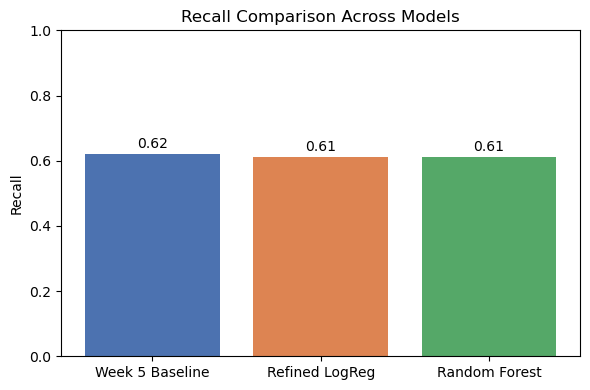

In [16]:
import matplotlib.pyplot as plt

models = ['Week 5 Baseline', 'Refined LogReg', 'Random Forest']
recall_scores = [0.62, 0.61, 0.61]

plt.figure(figsize=(6, 4))
plt.bar(models, recall_scores, color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylabel('Recall')
plt.title('Recall Comparison Across Models')
plt.ylim(0, 1)
for i, v in enumerate(recall_scores):
    plt.text(i, v + 0.02, str(v), ha='center')
plt.tight_layout()
plt.savefig('recall_comparison.png', dpi=150)
plt.show()

## Evaluation Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Week 5 Baseline (Logistic Regression) | 0.63 | 0.63 | 0.62 | 0.62 | 0.68 |
| Logistic Regression + both interaction features | 0.62 | 0.63 | 0.61 | 0.62 | 0.68 |
| Random Forest + both interaction features | 0.59 | 0.59 | 0.61 | 0.60 | 0.63 |

Before comparing models, the Week 6 test set was verified against Week 5's saved test set (966/966 rows identical), confirming both models were evaluated on the exact same data

Two independently validated, statistically significant interaction features were tested this week (`recent_and_sms`, from this notebook's own error analysis; `lead_and_prior_noshow`, from Data Analytics). Neither improved recall. The Week 5 baseline's 0.62 remains the best result across all three models, with the refined Logistic Regression essentially matching it (0.61) and Random Forest performing worse (0.61, with lower accuracy and ROC-AUC).

## Interpretation

Statistical significance and model improvement are not the same thing. Both engineered features were built from combinations of variables already present in the model (`booking_lead_days`, `previous_no_shows`, `reminder_channel`). So while each correlates strongly with no-show status on its own, they largely duplicate information the model already had access to individually. A t-test confirms a feature relates to the outcome 
*in general*; it says nothing about whether the model can extract additional, non-redundant signal from it once related features are already present.

This is a consistent pattern across two independent tests now, not a one-off result: neither this notebook's own engineered feature nor a well-validated cross-track suggestion moved recall. This points toward a **model-level limitation rather than a missing-feature 
problem**. The linear structure of Logistic Regression, or the untuned complexity of Random Forest, is more likely the cause here than the current feature set.

## Business Relevance

Since neither improvement attempt increased recall, the metric that matters most for HealthConnect, given missed no-shows are the costlier error so the original Week 5 baseline remains the strongest, most defensible option to move forward with. Adding complexity (more features, a more complex model) without a corresponding gain in recall would not serve HealthConnect's actual goal.

## Candidate Model Recommendation

**Recommended for the next stage: the Week 5 baseline Logistic Regression**, unchanged. 
Both interaction features tested this week are documented as valid, evidence-based attempts that did not improve performance. This is a meaningful negative result, not a wasted effort, since it rules out feature engineering as the fix and redirects Week 7 toward model-level 
work (hyperparameter tuning, threshold tuning) instead. Random Forest is not recommended in its current untuned form, though Week 5's reasoning for testing a non-linear model still holds pending proper tuning.

## Limitations, Risks & Dependencies

**Issues resolved (from Weeks 4/5):**
- The model still reliably catches the "high-risk" no-show profile (long lead time, prior no-shows, no reminder) I found in Week 5, this held up again in this week's error analysis.
- I resolved whether Claudia's reminder-channel finding was as strong as she reported. I checked it directly against my dataset and found a real but modest effect (54.6% vs 49.9%), not the near-universal pattern she described.

**Issues remaining unresolved:**
- The model is still blind to "safe-looking" no-shows (recent booking, clean history, got a reminder), this is the core gap my error analysis found and I haven't fixed it yet.
- The disagreement with Claudia over `distance_to_clinic_km` is still open, I've flagged it back to her but we haven't settled it.
- Angela's second suggestion (reminder × lead-time interaction) hasn't been tested yet.

**New issues discovered:**
- Two features I engineered this week (`recent_and_sms`, `lead_and_prior_noshow`) were both highly statistically significant but neither improved recall, this wasn't something I knew going into the week.
- `age` showed up with unexpectedly high importance in the Random Forest, even though it was only a borderline predictor in Week 5, and I don't have an explanation for that yet.

**New cross-track dependencies:**
- ML Engineering now needs my finalized feature list and candidate model recommendation for their pipeline work.

**Technical limitations:**
- I only tested Random Forest with default settings, I didn't tune anything (max_depth, min_samples_leaf, etc.).

**Data limitations:**
- My numbers differ slightly from both Claudia's and Angela's, most likely because of how Cancelled appointments were handled differently across our tracks.

**Modelling limitations:**
- Both features I engineered this week overlapped with variables already in the model (`booking_lead_days`, `previous_no_shows`, `reminder_channel`), which is probably why being statistically significant didn't actually move recall. This points to a model-level ceiling (linear boundary, or an untuned Random Forest) rather than a missing-feature problem.

**AI safety/reliability concerns:**
- Not applicable to my track's Week 6 work.

**Integration challenges:**
- Both findings I got from Data Analytics needed independent checking before I could actually use them, I couldn't just take either one at face value.

**Potential impact on the project:**
- Since I haven't fixed the "safe-looking" no-show blind spot yet, HealthConnect could still miss a real chunk of no-shows in practice, this is a live risk going into Week 7, not just a note on paper.

**Recommended mitigation:**
- Tune the Random Forest properly and re-compare against the baseline.
- Test different decision thresholds to try to catch more no-shows without over-flagging.
- Dig into why age matters more than expected in Random Forest.
- Test the model against ML Engineering's pipeline once that connection happens.
- Look at combinations of features together, not just one at a time.

## Cross-Track Contribution

**Track collaborated with:** Data Analytics (AMOUGOU NDI Claudia)

**Project dependency:** Data Science's Week 6 error analysis and feature review could be strengthened by validated patterns Data Analytics identified in their own analysis of no-show behaviour.

**Information/output received:** Claudia shared a finding that patients with no reminder_channel recorded had an unusually high no-show rate.

**Information/output provided:** In return, the finalized feature list, Random Forest feature importance ranking, and an explanation of how missing reminder_channel values were handled in the model (filled as an explicit "No Reminder" category) were shared with her.

**Integration activity completed:** Claudia's finding was directly tested against the dataset (a crosstab comparing no-show rate by presence/absence of reminder_channel) before being accepted or acted on.

**What changed as a result:** The validation showed the finding's direction was correct but its effect size was considerably smaller than described (54.6% vs 49.9% no-show rate which revealed a 5 point gap, not a near-universal pattern). This corrected, more accurate version of the 
finding was reported back to Claudia, and it confirmed that reminder-related features already in the model were capturing this effect appropriately, meaning no additional feature was needed on this specific point.

**Evidence:** Slack message exchange (shared feature list, importance ranking, and validation results), the validation crosstab and write-up in the Error Analysis section of this notebook.

---

**Track collaborated with (2):** Data Analytics (Iseriehen Angela)

**Project dependency:** Data Science's Week 6 error analysis and feature review could be strengthened by validated patterns Data Analytics identified around risk-factor combinations and reminder effectiveness.

**Information/output received:** Angela reviewed this track's actual Week 5 notebook and shared two evidence-backed interaction findings: (1) booking lead time and prior no-show history compound rather than act independently (no-show rate ranging from 22% to 70% depending on the combination, validated as consistent across all appointment types in her analysis), and (2) reminder channel effectiveness depends on lead time and SMS performs best overall, but Email outperforms it for short-notice (0-7 day) appointments.

**Information/output provided:** This track's finalized feature list, Random Forest feature importance ranking, and an explanation of reminder_channel's missing-value handling 

**Integration activity completed:** Angela's first finding (lead time × prior no-show) was directly validated against this dataset (confirmed consistent direction and pattern, with minor numeric differences attributed to Cancelled-appointment handling), then engineered as a feature (`lead_and_prior_noshow`) and statistically tested (T = -14.282, p < 0.0001).

**What changed as a result:** Despite strong statistical significance, adding this feature (alongside `recent_and_sms`) did not improve model recall  a genuine, documented result that redirected this week's conclusion toward a model-level limitation rather than a missing-feature problem. Angela's second suggestion (reminder × lead-time interaction) was noted but not tested this week, given this outcome.

**Evidence:** Slack message from Angela with both findings and her Week 6 notebook (`Week6_Advance_Analytics.ipynb`); the validation crosstab and t-test in this notebook's "Validating Data Analytics' Finding (Angela)" and "Feature Refinement" sections.

## Week 7 Testing Requirements

- **Tune the Random Forest properly.** This week's model used default settings only. I will adjust things like tree depth and number of trees to see if it can actually beat the baseline once it's properly set up.

- **Try different decision thresholds.** Right now the model just uses a 50/50 cutoff to decide "no-show" or "attended." I will test other cutoffs to see if I can catch more real shows without wrongly flagging too many people who would have shown up.

- **Look deeper into the age result.** Age came out more important in the Random Forest than expected, given it was a weak/borderline feature in Week 5. I will dig into this to find out if it's a real pattern or just noise from an untuned model.

- **Test the model with ML Engineering's pipeline**, if that connection happens, to make sure the model still works well outside this notebook.

- **Look at combinations of features, not just one at a time.** This week's error analysis looked at features individually. Next I'll check if specific *combinations* of features point to a clearer group of "hidden" no-shows that staff could focus on.